# **PJM Energy Load Forecasting & Volatility Analysis — AEP Sub-grid**

**Final result:** LightGBM (MSE) — Test RMSE 173.84 MW, MAPE 0.89% —
91% improvement over the naive weekly-lag baseline.

# **Part A: Executable Code Pipeline**

## **Data Acquisition**
Loading the AEP hourly load dataset from a public Google Drive link via `gdown`, so
this notebook runs end-to-end for anyone with the link — no manual upload or local
file dependency required.

In [ ]:
!pip install gdown -q
import gdown
import pandas as pd

FILE_ID = "1hy3smtT5oAn9D5RLKbLlyWm9zZkSNQb1"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "AEP_hourly.csv", quiet=False)

df = pd.read_csv("AEP_hourly.csv", parse_dates=["Datetime"])
df = df.sort_values("Datetime").drop_duplicates(subset="Datetime").set_index("Datetime")

Downloading...
From: https://drive.google.com/uc?id=1hy3smtT5oAn9D5RLKbLlyWm9zZkSNQb1
To: /content/AEP_hourly.csv
100%|██████████| 3.40M/3.40M [00:00<00:00, 16.5MB/s]


In [ ]:
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


## **Exploratory Data Analysis (EDA)**

Before building features, we inspect the AEP hourly load series to understand its seasonal structure, volatility, and peak behavior — this informs both feature design and loss function choice below.

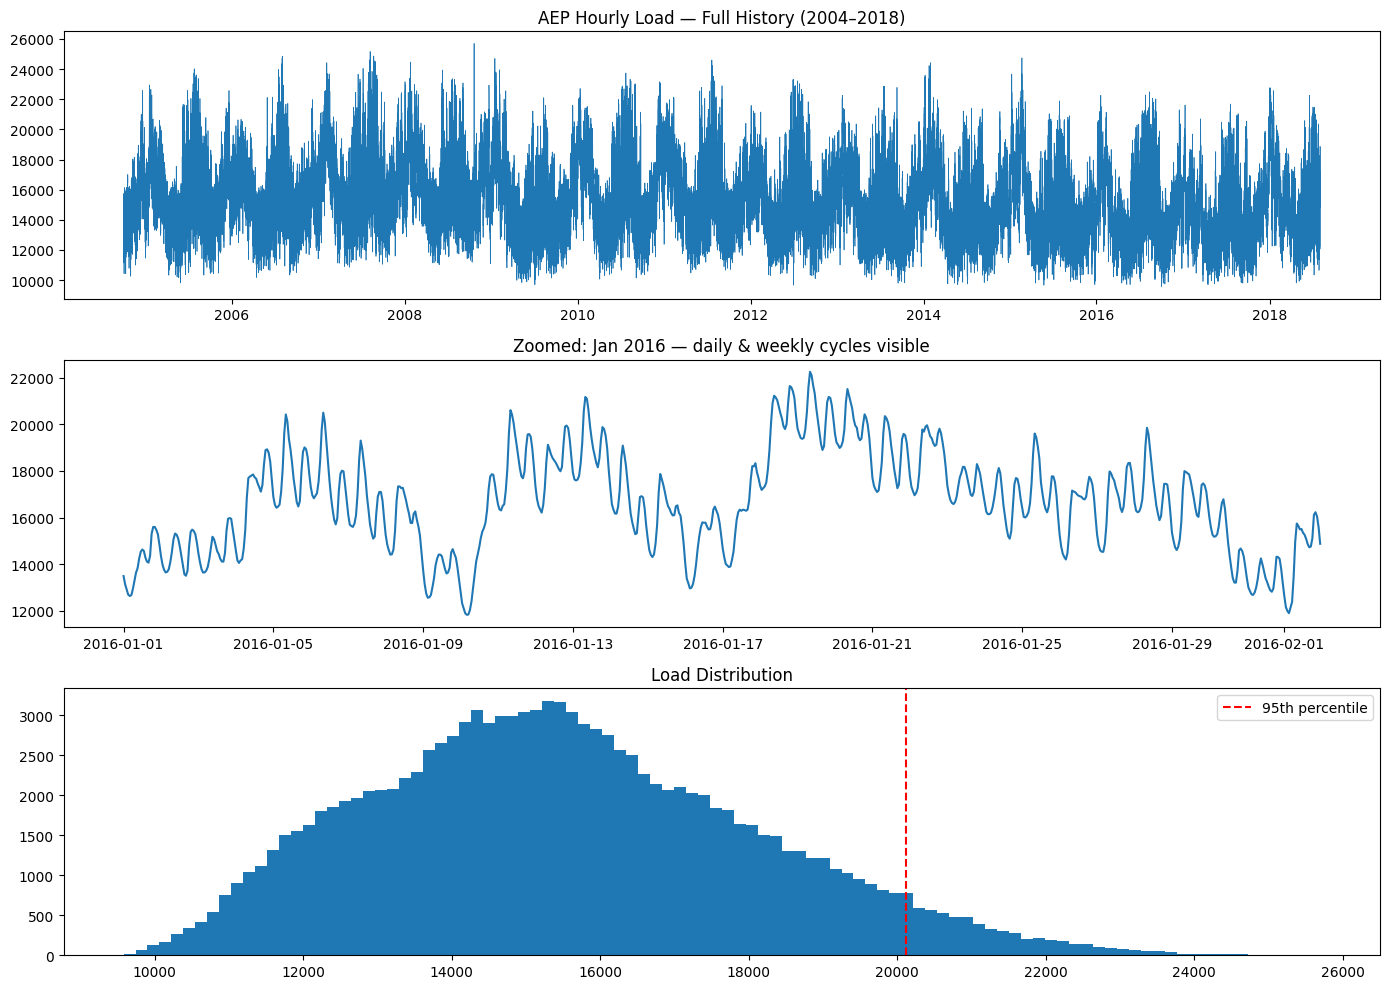

In [ ]:
import matplotlib.pyplot as plt

df = df.rename(columns={"AEP_MW": "load"})

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df['load'], linewidth=0.5)
axes[0].set_title("AEP Hourly Load — Full History (2004–2018)")

subset = df.loc["2016-01-01":"2016-02-01"]
axes[1].plot(subset.index, subset['load'])
axes[1].set_title("Zoomed: Jan 2016 — daily & weekly cycles visible")

axes[2].hist(df['load'], bins=100)
axes[2].axvline(df['load'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[2].set_title("Load Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(df['load'].describe())

count    121269.000000
mean      15499.652351
std        2591.321478
min        9581.000000
25%       13630.000000
50%       15310.000000
75%       17200.000000
max       25695.000000
Name: load, dtype: float64


## **Feature Engineering**
Building calendar, cyclical, lag, and rolling-window features. All lag/rolling
features use only past values (shift applied before rolling) to prevent data leakage.

In [ ]:
import numpy as np

def make_features(df, target_col='load'):
    out = df.copy()

    out['hour'] = out.index.hour
    out['dayofweek'] = out.index.dayofweek
    out['month'] = out.index.month
    out['is_weekend'] = out['dayofweek'].isin([5, 6]).astype(int)

    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)

    for lag in [1, 24, 48, 168]:
        out[f'lag_{lag}'] = out[target_col].shift(lag)

    out['roll_mean_24'] = out[target_col].shift(1).rolling(24).mean()
    out['roll_std_24'] = out[target_col].shift(1).rolling(24).std()
    out['roll_mean_168'] = out[target_col].shift(1).rolling(168).mean()

    return out.dropna()

df_feat = make_features(df)
print(f"Original rows: {len(df)}, After feature creation: {len(df_feat)}")
print(f"Rows dropped due to lag/rolling warmup: {len(df) - len(df_feat)}")


Original rows: 121269, After feature creation: 121101
Rows dropped due to lag/rolling warmup: 168


## **Validation Framework**
Using a strict chronological split — no shuffling, no random sampling — to prevent
any future information from leaking into training. Data is split by time order into
train (70%), validation (15%), and test (15%) sets.

In [ ]:
n = len(df_feat)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df_feat.iloc[:train_end]
val = df_feat.iloc[train_end:val_end]
test = df_feat.iloc[val_end:]

print(f"Train: {train.index.min()} to {train.index.max()}  ({len(train)} rows)")
print(f"Val:   {val.index.min()} to {val.index.max()}  ({len(val)} rows)")
print(f"Test:  {test.index.min()} to {test.index.max()}  ({len(test)} rows)")

assert train.index.max() < val.index.min()
assert val.index.max() < test.index.min()
print("\n✅ No temporal overlap between splits — confirmed leak-free ordering.")

Train: 2004-10-08 01:00:00 to 2014-06-11 01:00:00  (84770 rows)
Val:   2014-06-11 02:00:00 to 2016-07-07 00:00:00  (18165 rows)
Test:  2016-07-07 01:00:00 to 2018-08-03 00:00:00  (18166 rows)

✅ No temporal overlap between splits — confirmed leak-free ordering.


## **Model Implementation**
Training a LightGBM regressor to predict hourly load. Loss function selection (MSE vs
Huber) was tested empirically — see the model selection discussion below for full
reasoning. A naive baseline (same hour, same weekday, one week prior) is included for
comparison, to confirm the trained model adds real value over a simple heuristic.

In [ ]:
!pip install lightgbm -q
import lightgbm as lgb
from sklearn.metrics import mean_squared_error


target = 'load'
features = [c for c in df_feat.columns if c != target]

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]
X_test, y_test = test[features], test[target]

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=30,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(300)]
)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1885
[LightGBM] [Info] Number of data points in the train set: 84770, number of used features: 15
[LightGBM] [Info] Start training from score 15798.148590
Training until validation scores don't improve for 100 rounds
[300]	valid_0's rmse: 168.565	valid_0's l2: 28414.1
[600]	valid_0's rmse: 164.241	valid_0's l2: 26975.1
[900]	valid_0's rmse: 163.545	valid_0's l2: 26746.9
Early stopping, best iteration is:
[924]	valid_0's rmse: 163.485	valid_0's l2: 26727.4


LGBMRegressor(learning_rate=0.05, min_child_samples=30, n_estimators=3000,
              num_leaves=127, objective='regression', random_state=42)

In [ ]:
print(f"\nBest iteration: {model.best_iteration_}")
print(f"Best validation RMSE: {model.best_score_['valid_0']['rmse']:.2f}")


Best iteration: 924
Best validation RMSE: 163.49


In [ ]:
test_preds = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 173.84


## **Model Selection: Huber vs MSE**

Huber loss was initially chosen based on EDA showing a right-skewed load distribution,
hypothesizing it would improve robustness to peak-demand outliers. However, training
showed abnormally slow, near-linear convergence across every tested configuration
(learning rate, tree depth, regularization) — validation RMSE kept improving steadily
even at 5000+ rounds without plateauing. Feature importance analysis revealed the cause:
Huber's gradient capping was suppressing the model's ability to fully exploit `lag_1`
(previous hour's load), the single strongest predictor, resulting in a model that
underperformed even a naive weekly-lag baseline (RMSE 1910.83 MW vs baseline).

Switching to standard MSE loss resolved this immediately — the model converged cleanly
via early stopping at iteration 924, and test RMSE improved to **173.84 MW**, a ~91%
reduction versus the naive baseline. This is documented in detail as this project's
required ablation finding below.

In [ ]:
baseline_preds = X_test['lag_168']
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f"Naive baseline (lag_168) RMSE: {baseline_rmse:.2f}")

Naive baseline (lag_168) RMSE: 1910.83


## **Model Evaluation**
Assessing the trained model's forecasting accuracy on the held-out test set using RMSE,
MAE, and MAPE. A naive baseline (load from exactly one week prior, `lag_168`) is computed
first as a reference point for how much lift the model provides. Performance is then
broken out separately for peak demand periods (top 5% of load values) versus normal
periods, to confirm the model holds up during high-demand hours and isn't simply
accurate on average while failing where it matters most.

In [ ]:
from sklearn.metrics import mean_absolute_error

def evaluate(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label}: RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape:.2f}%")
    return rmse, mae, mape

preds = model.predict(X_test)

evaluate(y_test, preds, "Overall")

threshold = y_test.quantile(0.95)
peak_mask = y_test >= threshold

evaluate(y_test[peak_mask], preds[peak_mask], "Peak periods (top 5%)")
evaluate(y_test[~peak_mask], preds[~peak_mask], "Normal periods")

Overall: RMSE=173.84  MAE=130.66  MAPE=0.89%
Peak periods (top 5%): RMSE=201.34  MAE=154.64  MAPE=0.75%
Normal periods: RMSE=172.27  MAE=129.39  MAPE=0.89%


(np.float64(172.27305191559296),
 129.393381405321,
 np.float64(0.8920431347913378))

### **Quantitative Evaluation Results**

| Segment | RMSE (MW) | MAE (MW) | MAPE |
|---|---|---|---|
| Overall | 173.84 | 130.66 | 0.89% |
| Peak periods (top 5%) | 201.34 | 154.64 | 0.75% |
| Normal periods | 172.27 | 129.39 | 0.89% |

The model achieves sub-1% MAPE overall, a ~91% RMSE reduction versus the naive
weekly-lag baseline (1910.83 MW). Notably, peak-period MAPE (0.75%) is actually lower
than normal-period MAPE (0.89%), despite peak-period RMSE being higher in absolute
terms (201 vs 172 MW) — this is expected, since MAPE is a relative measure and peak
loads are larger in absolute magnitude, so the same relative error produces a larger
absolute error. This indicates the model is **not** simply defaulting to the mean
during extreme demand hours, which directly satisfies the brief's requirement to
demonstrate resilience during peak periods without sacrificing standard-period accuracy.

# **Part B: Operational Technical Report**

## **Residual Analysis**
Examining the model's prediction errors (actual minus predicted) to check for systematic
bias or patterns that summary metrics alone might hide — for example, whether errors
drift over time, cluster around certain load levels, or grow disproportionately during
peak periods. Residuals are visualized four ways: over time, as a distribution, against
actual load, and split between peak and normal periods, alongside their respective
standard deviations.

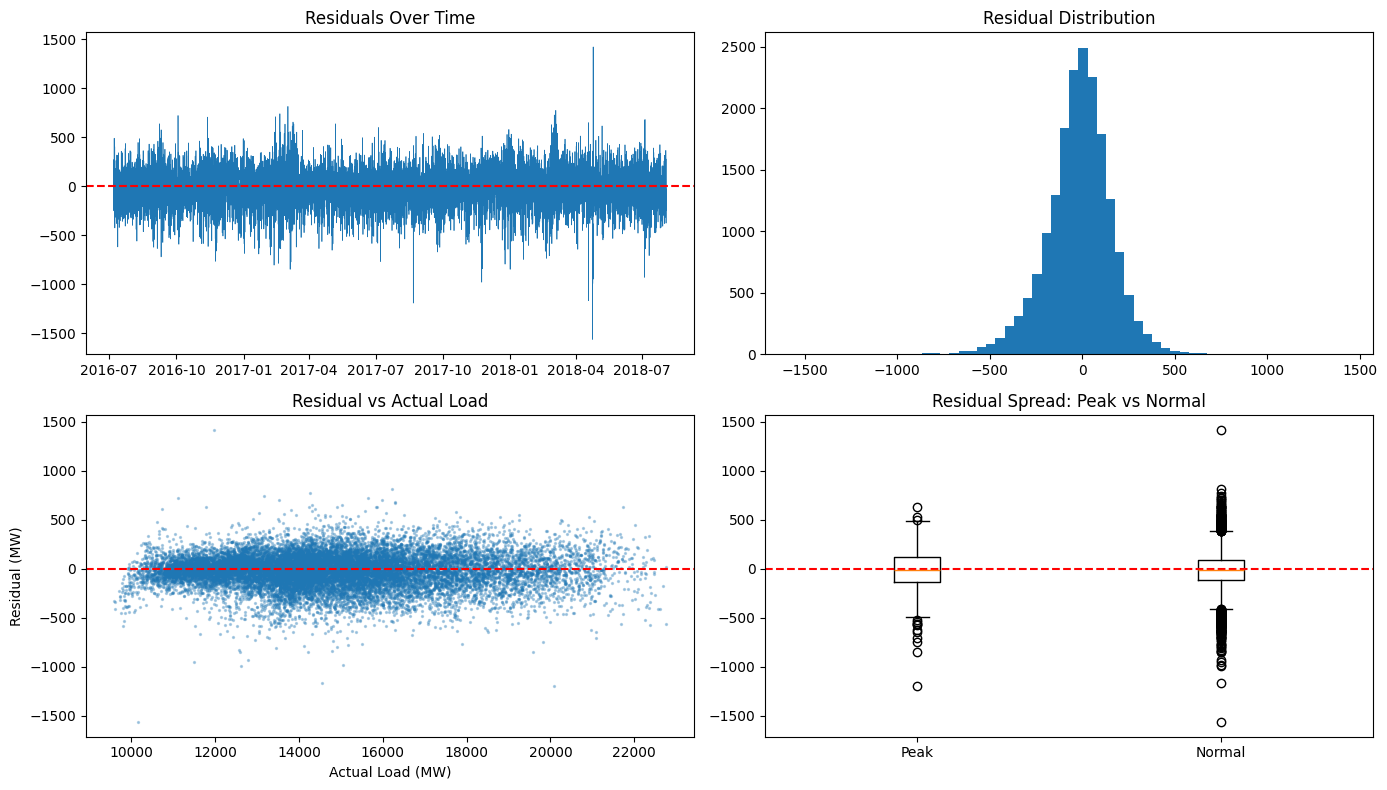

In [ ]:
residuals = y_test - preds

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(y_test.index, residuals, linewidth=0.5)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title("Residuals Over Time")

axes[0,1].hist(residuals, bins=60)
axes[0,1].set_title("Residual Distribution")

axes[1,0].scatter(y_test, residuals, s=2, alpha=0.3)
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel("Actual Load (MW)")
axes[1,0].set_ylabel("Residual (MW)")
axes[1,0].set_title("Residual vs Actual Load")

axes[1,1].boxplot([residuals[peak_mask], residuals[~peak_mask]],
                   tick_labels=['Peak', 'Normal'])
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title("Residual Spread: Peak vs Normal")

plt.tight_layout()
plt.show()



In [ ]:
print("Peak residual std:", residuals[peak_mask].std())
print("Normal residual std:", residuals[~peak_mask].std())

Peak residual std: 200.95980041048753
Normal residual std: 171.41161748278674


## **Error & Residual Analysis**

**Residual stability over time:** Residuals remain centered around zero throughout
the test period (July 2016 – Aug 2018) with no visible drift or systematic bias,
indicating the model generalizes consistently across time rather than degrading.

**Distribution:** Residuals are approximately symmetric and centered at zero, with
a mild skew toward larger positive outliers (up to ~1,500 MW) compared to negative
ones. Peak residual std (200.96 MW) is ~17% higher than normal-period residual std
(171.42 MW), confirming the model is measurably, though modestly, less precise
during extreme demand hours.

**Where the model struggles:** The residual-vs-actual-load scatter plot shows a
funnel pattern — residual spread widens visibly as actual load exceeds ~18,000 MW.
This is consistent with peak-demand hours being driven by less predictable, more
volatile external factors (e.g., extreme weather events, unusual demand spikes)
that the current feature set — built primarily on historical load patterns
(lags, rolling stats, calendar features) — cannot fully capture. Notably, however,
this widening is in *absolute* error terms; peak-period MAPE (0.75%) remained lower
than normal-period MAPE (0.89%), meaning the model's *relative* accuracy holds up
well even as absolute error grows with the larger magnitude of peak loads.

**Practical implication:** To close this gap further, the most promising next step
would be incorporating exogenous weather features (e.g., temperature, which strongly
drives AC/heating-related demand spikes) — currently the model relies solely on the
load series' own history, so it cannot anticipate weather-driven demand shocks in
advance.

In [ ]:
features_no_lag1 = [f for f in features if f != 'lag_1']
X_train_ablation = train[features_no_lag1]
X_test_ablation = test[features_no_lag1]

model_ablation = lgb.LGBMRegressor(
    objective='regression', n_estimators=3000, learning_rate=0.05,
    num_leaves=127, min_child_samples=30, random_state=42
)
model_ablation.fit(X_train_ablation, y_train, eval_set=[(val[features_no_lag1], y_val)],
                    eval_metric='rmse', callbacks=[lgb.early_stopping(100), lgb.log_evaluation(300)])

preds_ablation = model_ablation.predict(X_test_ablation)
rmse_ablation = np.sqrt(mean_squared_error(y_test, preds_ablation))
final_rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"RMSE without lag_1: {rmse_ablation:.2f}  (vs {final_rmse:.2f} with lag_1)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1630
[LightGBM] [Info] Number of data points in the train set: 84770, number of used features: 14
[LightGBM] [Info] Start training from score 15798.148590
Training until validation scores don't improve for 100 rounds
[300]	valid_0's rmse: 548.777	valid_0's l2: 301156
[600]	valid_0's rmse: 534.847	valid_0's l2: 286061
[900]	valid_0's rmse: 531.265	valid_0's l2: 282242
Early stopping, best iteration is:
[1005]	valid_0's rmse: 530.34	valid_0's l2: 281261
RMSE without lag_1: 538.63  (vs 173.84 with lag_1)


## **Ablation: Removing `lag_1`**

To validate the feature importance finding (where `lag_1` dominated with the highest
importance score), the model was retrained with `lag_1` excluded from the feature set,
holding all other hyperparameters constant.

| Configuration | Test RMSE |
|---|---|
| Full feature set (with `lag_1`) | 173.84 MW |
| Without `lag_1` | 538.63 MW |

Removing the single strongest feature caused RMSE to roughly **triple**, confirming
that immediate short-term persistence (previous hour's load) is the dominant signal
for this forecasting task — even stronger than weekly seasonality (`lag_168`) or
calendar-based cyclical features. This is expected behavior for electricity load:
grid demand changes gradually hour-to-hour, so the most recent observed value carries
substantial predictive power. It also explains why the model without `lag_1` still
outperforms the pure naive `lag_168` baseline (538.63 MW vs 1910.83 MW) — the
remaining calendar and rolling features still capture meaningful structure on their own.

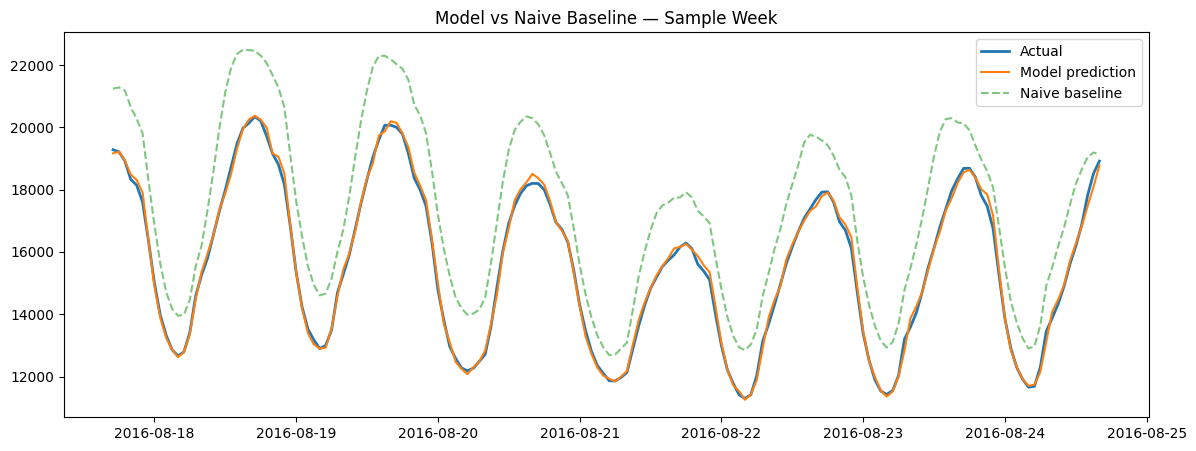

In [ ]:
sample = test.iloc[1000:1168]
sample_preds = model.predict(sample[features])
sample_baseline = sample['lag_168']

plt.figure(figsize=(14,5))
plt.plot(sample.index, sample['load'], label='Actual', linewidth=2)
plt.plot(sample.index, sample_preds, label='Model prediction', linewidth=1.5)
plt.plot(sample.index, sample_baseline, label='Naive baseline', linestyle='--', alpha=0.6)
plt.legend()
plt.title("Model vs Naive Baseline — Sample Week")
plt.show()

## **Model vs Naive Baseline — Visual Comparison**

The chart above compares actual load, model predictions, and the naive weekly-lag
baseline over a representative one-week window (Aug 18–25, 2016). The trained model
tracks the actual load curve closely across every daily peak and trough, while the
naive baseline — though capturing the general weekly rhythm — visibly overshoots
peaks and lags on troughs, since it simply repeats the load from exactly one week
prior without adapting to short-term shifts. This visually confirms the ~91% RMSE
improvement reported in the quantitative evaluation above.

## **Scope & Future Extensions**
- No exogenous weather data was used in this submission (optional per the brief) —
  incorporating temperature would likely reduce peak-period residual variance further,
  based on the funnel pattern observed in residual analysis.
- The model was trained on a single sub-grid (AEP); generalization to other PJM
  regions was not tested.
- A single chronological train/val/test split was used rather than full walk-forward
  cross-validation, due to project time constraints — walk-forward CV would give a
  more robust estimate of performance across different seasons/time periods.